# AI Intermediate Tasks — YoungDev Interns
### 01 Month Remote Internship
---
| Task | Topic |
|------|-------|
| 1 | Implement a Neural Network (MLP) |
| 2 | Data Preprocessing Pipeline |
| 3 | K-Fold Cross-Validation with Performance Metrics |


---
## Task 1 — Implement a Neural Network (MLP)
Build and train a Multi-Layer Perceptron on the Digits dataset. Evaluate with accuracy and a confusion matrix.


In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

# ── Load Data ─────────────────────────────────────────────────────────────────
digits = load_digits()
X, y   = digits.data, digits.target

print(f"Dataset shape : {X.shape}  (64 pixel features per 8x8 image)")
print(f"Classes       : {np.unique(y)}")


Dataset shape : (1797, 64)  (64 pixel features per 8x8 image)
Classes       : [0 1 2 3 4 5 6 7 8 9]


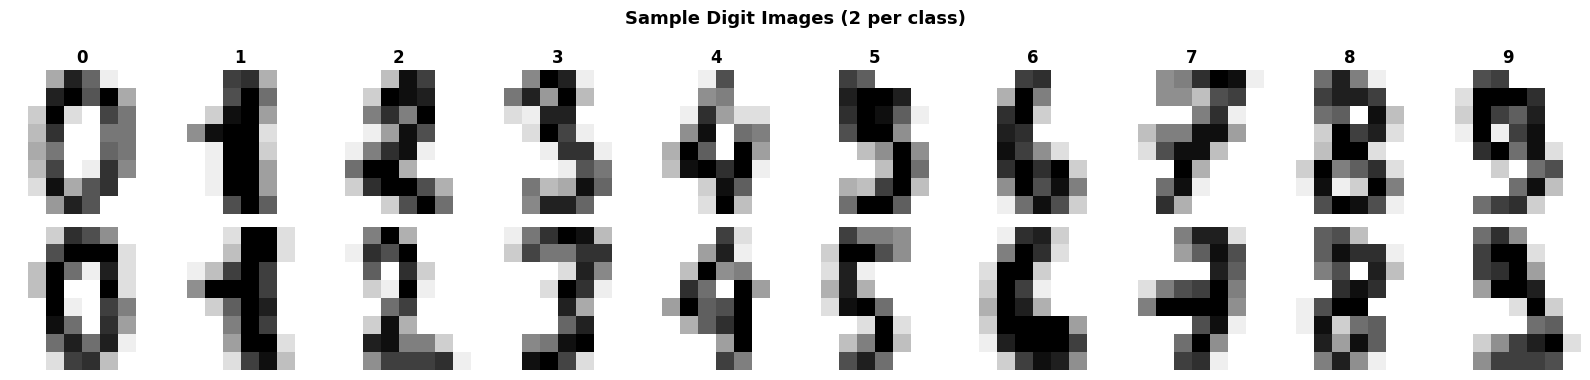

In [3]:
# ── Preview Sample Images ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
for digit in range(10):
    for row, pick in enumerate([0, 2]):
        idx = np.where(y == digit)[0][pick]
        axes[row, digit].imshow(digits.images[idx], cmap='gray_r')
        if row == 0:
            axes[row, digit].set_title(str(digit), fontsize=12, fontweight='bold')
        axes[row, digit].axis('off')
plt.suptitle('Sample Digit Images (2 per class)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [4]:
# ── Preprocess & Split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler  = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

print(f"Train: {X_tr_sc.shape}  |  Test: {X_te_sc.shape}")


Train: (1437, 64)  |  Test: (360, 64)


In [5]:
# ── Build & Train MLP ─────────────────────────────────────────────────────────
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
mlp.fit(X_tr_sc, y_train)

print(f"Stopped at iteration  : {mlp.n_iter_}")
print(f"Best validation score : {mlp.best_validation_score_:.4f}")


Stopped at iteration  : 31
Best validation score : 0.9861


In [6]:
# ── Evaluate ──────────────────────────────────────────────────────────────────
y_pred = mlp.predict(X_te_sc)
acc    = accuracy_score(y_test, y_pred)
print(f"Test Accuracy : {acc:.4f} ({acc*100:.2f}%)")
print()
print(classification_report(y_test, y_pred))


Test Accuracy : 0.9722 (97.22%)

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.94      0.94      0.94        36
           2       0.90      1.00      0.95        35
           3       1.00      0.97      0.99        37
           4       0.97      1.00      0.99        36
           5       1.00      0.97      0.99        37
           6       1.00      1.00      1.00        36
           7       0.97      1.00      0.99        36
           8       0.97      0.89      0.93        35
           9       0.97      0.97      0.97        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



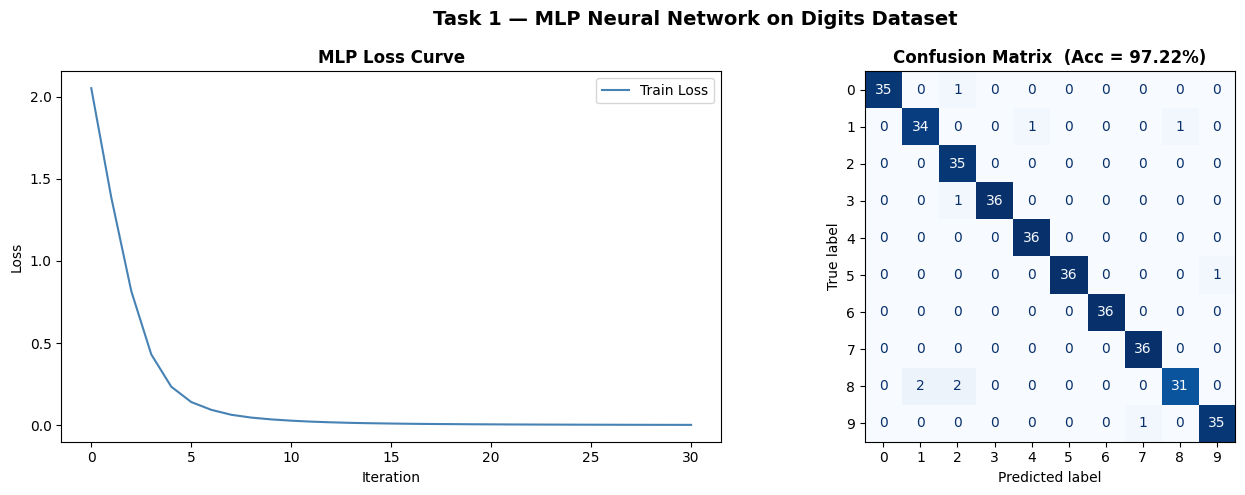

Task 1 complete!


In [8]:
# ── Loss Curve + Confusion Matrix ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(mlp.loss_curve_, color='steelblue', label='Train Loss')
axes[0].set_title('MLP Loss Curve', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Loss'); axes[0].legend()

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Confusion Matrix  (Acc = {acc:.2%})', fontsize=12, fontweight='bold')

plt.suptitle('Task 1 — MLP Neural Network on Digits Dataset',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("Task 1 complete!")


---
## Task 2 — Data Preprocessing Pipeline
Handle missing values, encode categoricals, normalise features, and split into train/test sets.


In [9]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

# ── Create Synthetic Raw Dataset ──────────────────────────────────────────────
np.random.seed(0)
n = 300

df_raw = pd.DataFrame({
    'age'       : np.random.randint(18, 70, n).astype(float),
    'income'    : np.random.normal(55000, 20000, n),
    'education' : np.random.choice(['High School', 'Bachelor', 'Master', 'PhD', None], n),
    'gender'    : np.random.choice(['Male', 'Female', 'Other', None], n),
    'purchased' : np.random.choice([0, 1], n),
})

# Inject missing values
df_raw.loc[np.random.choice(n, 30, replace=False), 'age']    = np.nan
df_raw.loc[np.random.choice(n, 25, replace=False), 'income'] = np.nan

print("Raw Dataset Shape:", df_raw.shape)
print("\nMissing Values:")
print(df_raw.isnull().sum())
print("\nSample:")
df_raw.head(8)


Raw Dataset Shape: (300, 5)

Missing Values:
age          30
income       25
education    51
gender       74
purchased     0
dtype: int64

Sample:


,age,income,education,gender,purchased
0,62.0,58333.469907,Bachelor,None,0
1,65.0,67700.628738,Bachelor,Male,1
2,18.0,102662.895497,None,None,0
3,21.0,73889.589740,Bachelor,Male,1
4,21.0,36743.555491,None,Male,1
5,57.0,77340.325762,High School,Male,1
6,27.0,28681.851790,None,None,1
7,37.0,45768.307904,PhD,None,0


In [10]:
# ── Step 1: Handle Missing Values ────────────────────────────────────────────
df = df_raw.copy()

num_imputer = SimpleImputer(strategy='median')
df[['age', 'income']] = num_imputer.fit_transform(df[['age', 'income']])

cat_imputer = SimpleImputer(strategy='most_frequent')
df[['education', 'gender']] = cat_imputer.fit_transform(df[['education', 'gender']])

print("Missing values after imputation:", df.isnull().sum().sum())


Missing values after imputation: 125


In [11]:
# ── Step 2: Encode Categorical Variables ──────────────────────────────────────
le_edu    = LabelEncoder()
le_gender = LabelEncoder()

df['education_enc'] = le_edu.fit_transform(df['education'])
df['gender_enc']    = le_gender.fit_transform(df['gender'])

print("Education mapping:", dict(zip(le_edu.classes_, le_edu.transform(le_edu.classes_))))
print("Gender mapping   :", dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_))))

df.drop(columns=['education', 'gender'], inplace=True)
print("\nDataFrame after encoding:")
print(df.head())


Education mapping: {'Bachelor': 0, 'High School': 1, 'Master': 2, 'PhD': 3, None: 4}
Gender mapping   : {'Female': 0, 'Male': 1, 'Other': 2, None: 3}

DataFrame after encoding:
    age         income  purchased  education_enc  gender_enc
0  62.0   58333.469907          0              0           3
1  65.0   67700.628738          1              0           1
2  18.0  102662.895497          0              4           3
3  21.0   73889.589740          1              0           1
4  21.0   36743.555491          1              4           1


In [12]:
# ── Step 3: Normalise Numerical Features ──────────────────────────────────────
num_cols = ['age', 'income']
scaler   = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

print("After MinMax scaling (values now in [0, 1]):")
print(df[num_cols].describe().round(3))


After MinMax scaling (values now in [0, 1]):
           age   income
count  300.000  300.000
mean     0.487    0.517
std      0.285    0.180
min      0.000    0.000
25%      0.255    0.408
50%      0.471    0.513
75%      0.706    0.641
max      1.000    1.000


In [13]:
# ── Step 4: Train / Test Split ────────────────────────────────────────────────
feature_cols = [c for c in df.columns if c != 'purchased']
X_pre = df[feature_cols].values
y_pre = df['purchased'].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X_pre, y_pre, test_size=0.2, random_state=42, stratify=y_pre)

print(f"Train : {X_tr.shape}  |  Test : {X_te.shape}")
print(f"Class balance (train) : {np.bincount(y_tr)}")
print(f"Class balance (test)  : {np.bincount(y_te)}")


Train : (240, 4)  |  Test : (60, 4)
Class balance (train) : [120 120]
Class balance (test)  : [30 30]


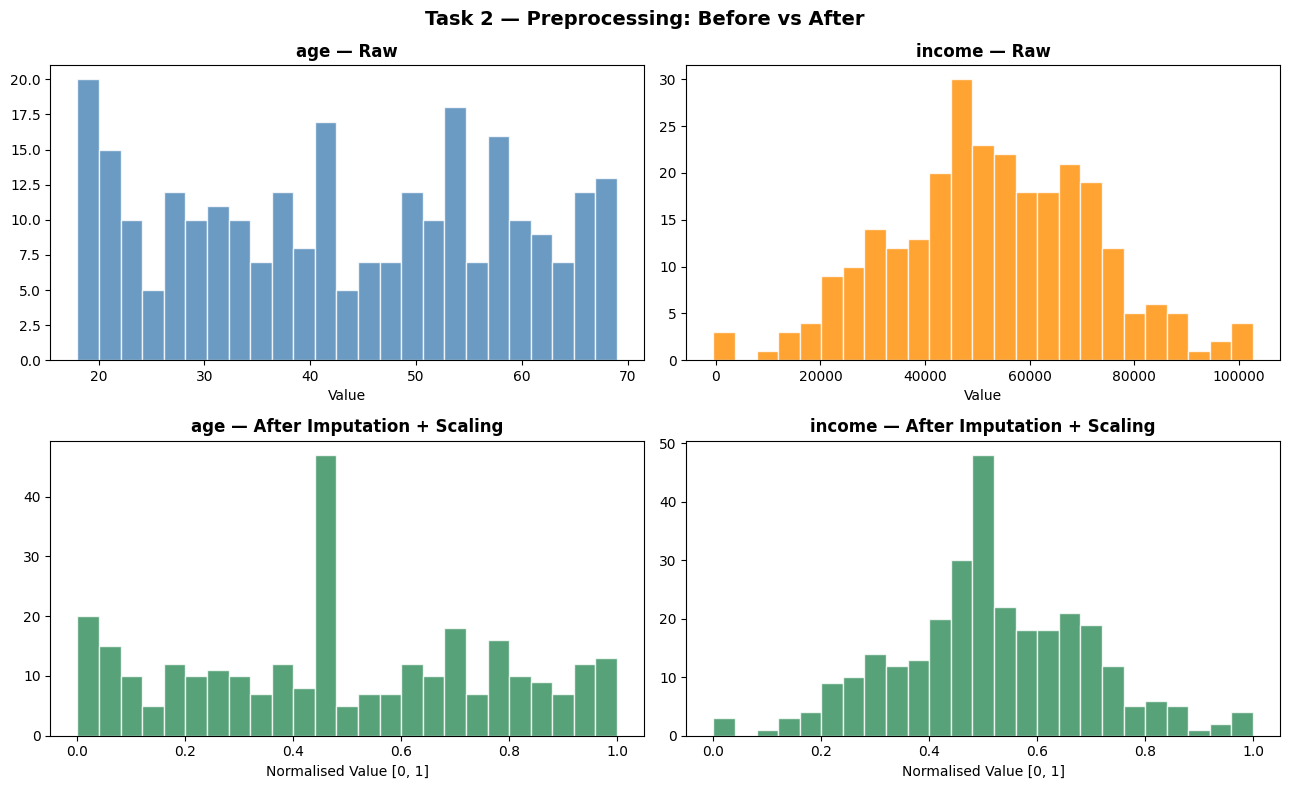

Task 2 complete!


In [14]:
# ── Before vs After Visualisation ────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for col, ax_raw, ax_proc, color in zip(
        ['age', 'income'],
        [axes[0, 0], axes[0, 1]],
        [axes[1, 0], axes[1, 1]],
        ['steelblue', 'darkorange']):
    ax_raw.hist(df_raw[col].dropna(), bins=25, color=color, alpha=0.8, edgecolor='white')
    ax_raw.set_title(f'{col} — Raw', fontweight='bold')
    ax_raw.set_xlabel('Value')

    ax_proc.hist(df[col], bins=25, color='seagreen', alpha=0.8, edgecolor='white')
    ax_proc.set_title(f'{col} — After Imputation + Scaling', fontweight='bold')
    ax_proc.set_xlabel('Normalised Value [0, 1]')

plt.suptitle('Task 2 — Preprocessing: Before vs After', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("Task 2 complete!")


---
## Task 3 — K-Fold Cross-Validation with Performance Metrics
Evaluate Random Forest and SVM using 10-fold Stratified K-Fold CV. Report accuracy, precision, recall, and F1.


In [15]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# ── Load Data ─────────────────────────────────────────────────────────────────
bc = load_breast_cancer(as_frame=True)
X_bc, y_bc = bc.data, bc.target

scaler  = StandardScaler()
X_bc_sc = scaler.fit_transform(X_bc)

print(f"Dataset  : Breast Cancer Wisconsin")
print(f"Samples  : {X_bc.shape[0]}  |  Features : {X_bc.shape[1]}")
print(f"Classes  : {bc.target_names}  |  Positive: {y_bc.sum()}  Negative: {(y_bc==0).sum()}")


Dataset  : Breast Cancer Wisconsin
Samples  : 569  |  Features : 30
Classes  : ['malignant' 'benign']  |  Positive: 357  Negative: 212


In [16]:
# ── 10-Fold Cross-Validation ──────────────────────────────────────────────────
skf     = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1']

models = {
    'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)'     : SVC(kernel='rbf', C=1.0, random_state=42),
}

results = {}
for name, clf in models.items():
    cv_res = cross_validate(clf, X_bc_sc, y_bc, cv=skf,
                            scoring=scoring, return_train_score=False)
    results[name] = {s: cv_res[f'test_{s}'] for s in scoring}
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    for s in scoring:
        vals = results[name][s]
        print(f"  {s:12s}: {vals.mean():.4f}  +/-  {vals.std():.4f}")



  Random Forest
  accuracy    : 0.9561  +/-  0.0239
  precision   : 0.9627  +/-  0.0331
  recall      : 0.9692  +/-  0.0232
  f1          : 0.9654  +/-  0.0183

  SVM (RBF)
  accuracy    : 0.9754  +/-  0.0195
  precision   : 0.9784  +/-  0.0199
  recall      : 0.9833  +/-  0.0283
  f1          : 0.9805  +/-  0.0157


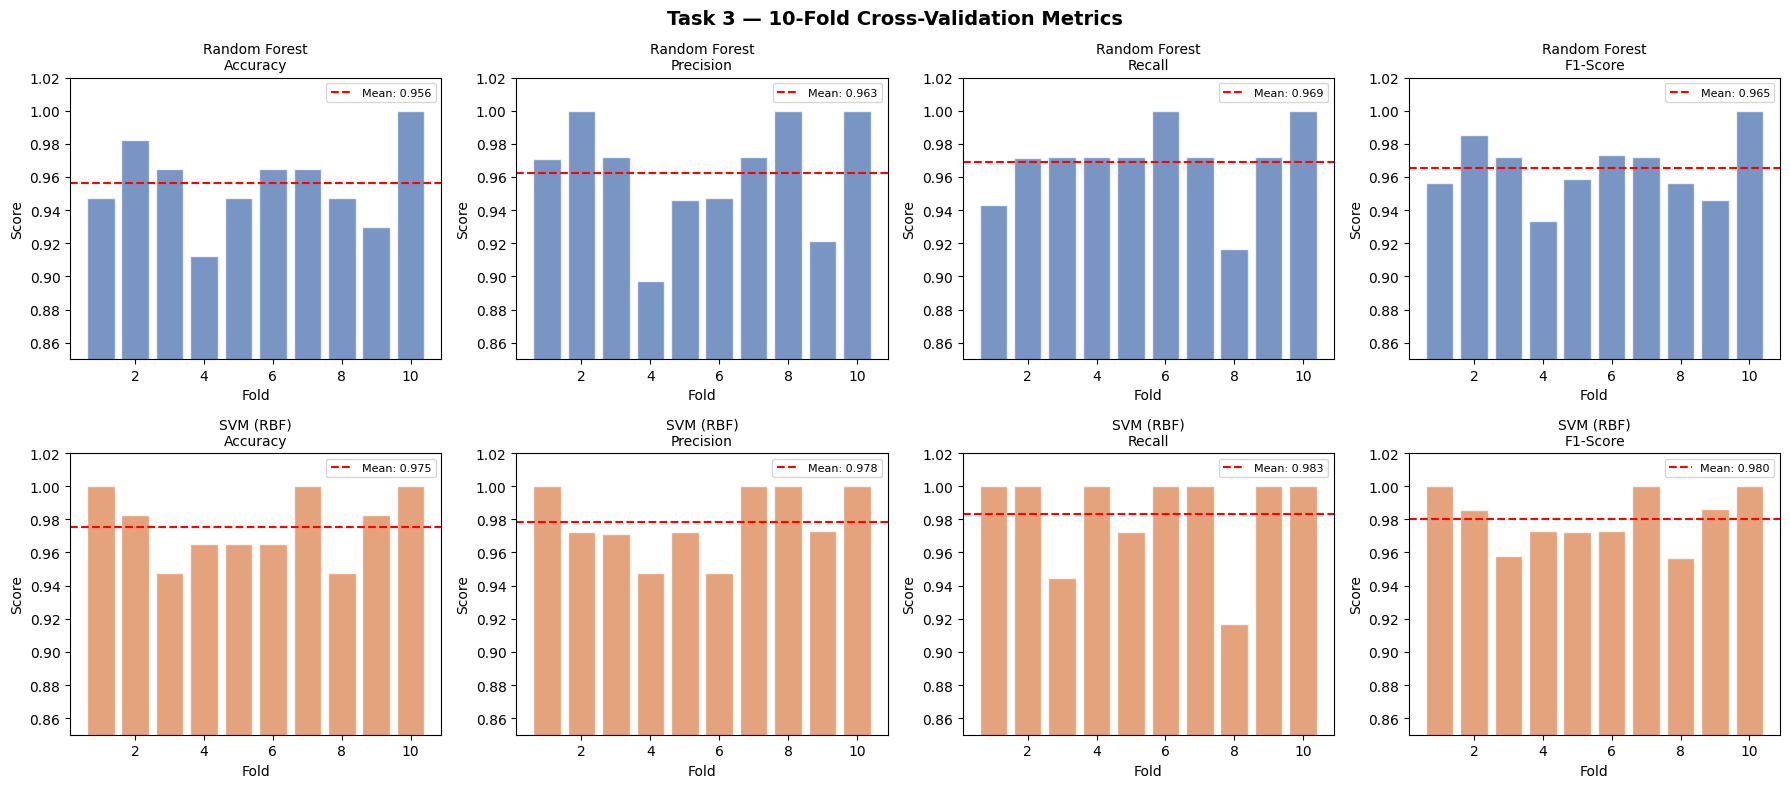

In [17]:
# ── Per-Fold Metric Plots ─────────────────────────────────────────────────────
metric_labels = {'accuracy': 'Accuracy', 'precision': 'Precision',
                 'recall': 'Recall', 'f1': 'F1-Score'}
colors = ['#4C72B0', '#DD8452']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for row, (name, color) in enumerate(zip(models.keys(), colors)):
    for col, metric in enumerate(scoring):
        vals  = results[name][metric]
        folds = range(1, len(vals) + 1)
        axes[row, col].bar(folds, vals, color=color, alpha=0.75, edgecolor='white')
        axes[row, col].axhline(vals.mean(), color='red', linestyle='--', lw=1.5,
                               label=f'Mean: {vals.mean():.3f}')
        axes[row, col].set_ylim(0.85, 1.02)
        axes[row, col].set_title(f'{name}\n{metric_labels[metric]}', fontsize=10)
        axes[row, col].set_xlabel('Fold')
        axes[row, col].set_ylabel('Score')
        axes[row, col].legend(fontsize=8)

plt.suptitle('Task 3 — 10-Fold Cross-Validation Metrics',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


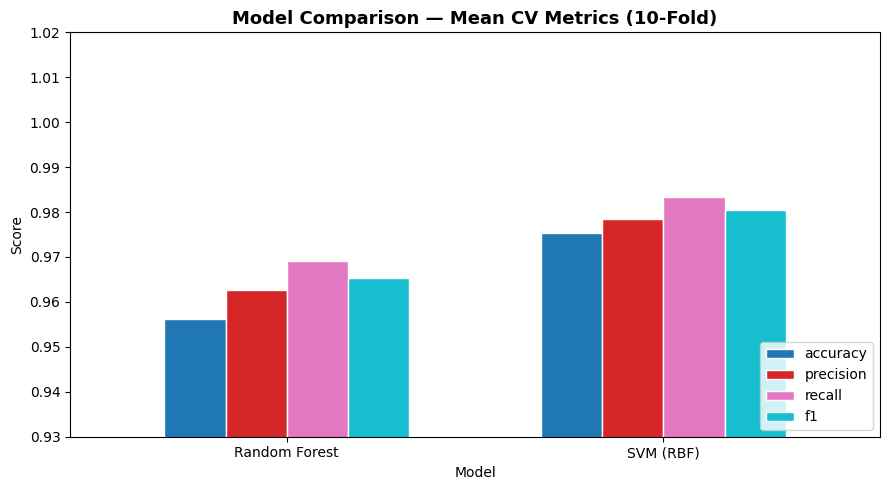

Task 3 complete!


In [18]:
# ── Summary Comparison Bar Chart ─────────────────────────────────────────────
summary = pd.DataFrame({
    name: {m: results[name][m].mean() for m in scoring}
    for name in models
}).T

ax = summary.plot(kind='bar', figsize=(9, 5), colormap='tab10',
                  edgecolor='white', width=0.65)
ax.set_ylim(0.93, 1.02)
ax.set_title('Model Comparison — Mean CV Metrics (10-Fold)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Model'); ax.set_ylabel('Score')
ax.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print("Task 3 complete!")
